<a href="https://colab.research.google.com/github/ga4gh/analytics-dashboard/blob/plenary-proof-of-concept/notebooks/Analytics_Dashboard_Demo.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Github Analytics Dashboard Demo
### A statistical look at the Github repos of GA4GH

In this notebook you will be able to create graphs displaying details about some of GA4GH's most popular repos!

To see the dashboard in action, run the cells in order from top to bottom.

In [4]:
'''
Some functions to fetch the data that we will be using
'''

import requests
import json
import dash
import pandas
from typing import List, Optional, Dict, Any

GH_BASE_URL = "http://AnalyticsDashboardAlbBalancer-1386294349.us-east-2.elb.amazonaws.com:8000/github/name/"
GH_API_URL = "https://api.github.com"
GH_repos = "https://api.github.com/orgs/ga4gh/repos"

names = []; url = GH_repos;
while url:
    r = requests.get(url); r.raise_for_status();
    names.extend([repo["name"] for repo in r.json()]);
    url = r.links.get("next", {}).get("url");
repos_list = names[:128]

def get_repos(endpoint: str, list_of_repos: List[str]) -> List[Dict[str, Any]]:

    items: List[Dict[str, Any]] = []
    url = endpoint

    for repo in list_of_repos:
        resp = requests.get(url + repo)
        resp.raise_for_status()
        items.append(resp.json()[0])

    return items

def get_json(endpoint: str, token: Optional[str] = None, per_page: int = 100) -> List[Dict[str, Any]]:

    headers = {}
    if token:
        headers["Authorization"] = f"token {token}"

    params = {"per_page": per_page, "page": 1}
    items: List[Dict[str, Any]] = []
    url = endpoint

    while True:
        resp = requests.get(url, headers=headers, params=params, timeout=30)
        resp.raise_for_status()
        data = resp.json()

        if not isinstance(data, list):
            return data

        items.extend(data)

        if "next" in resp.links:
            url = resp.links["next"]["url"]
            params = None
        else:
            break

    return items

## A Look at User Interactions with GA4GH Repos

Some of the main ways a user can show interest in a repository on github is to watch, fork, or subscribe to a repo.
- **Watchers**: Are users who have selected to recieve notifications about general activity in a repository
- **Subscribers**: Are users who want to know about specific issues within a repo such as open issues or pull request
- **Forks**: Are the ultimate form of interaction as it means a user loves the repo so much they have chosen to create their own personal copy so they can modify the code however they like

The cell below will generate a stacked bar graph with watchers + subscribers + forks. Hover over the segments of the bar to see the exact number of watchers, subscribers, or forks!

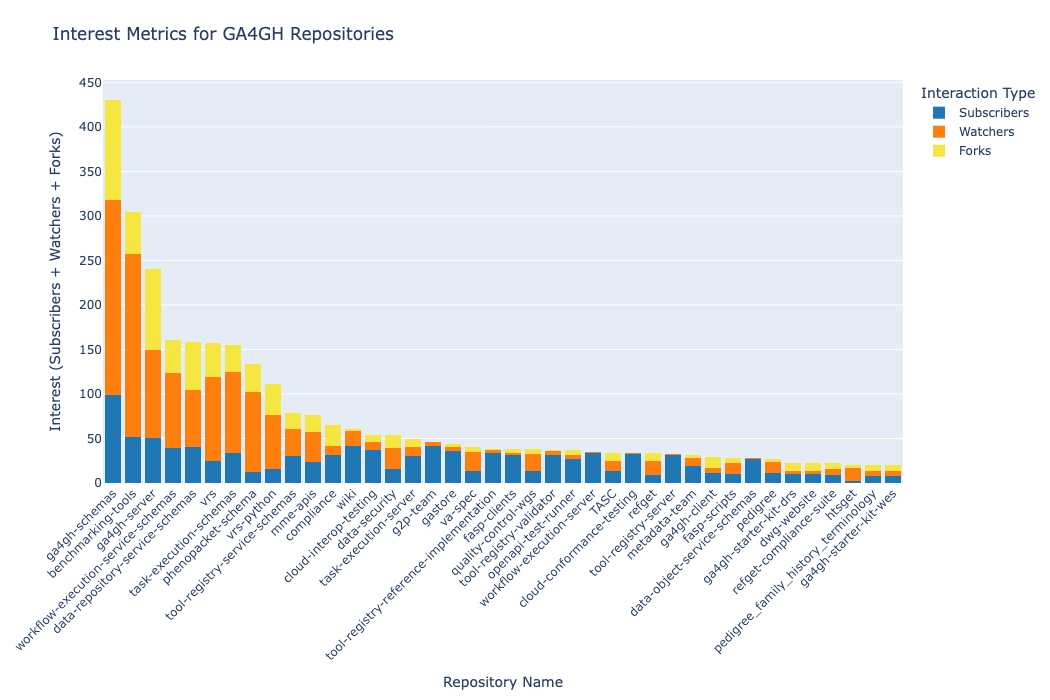

In [ ]:
from dash import Dash, dcc, html, Input, Output, callback
import plotly.express as px
import pandas as pd

GA4GH_repos = get_repos(GH_BASE_URL, repos_list)
GA4GH_repos_names = [repo['name'] for repo in GA4GH_repos]
GA4GH_repos_subscribers = [repo['subscribers_count'] for repo in GA4GH_repos]
GA4GH_repos_watchers = [repo['watchers_count'] for repo in GA4GH_repos]
GA4GH_repos_forks = [repo['forks_count'] for repo in GA4GH_repos]

df = pd.DataFrame({
    "Repo": GA4GH_repos_names,
    "Subscribers": GA4GH_repos_subscribers,
    "Forks": GA4GH_repos_forks,
    "Watchers": GA4GH_repos_watchers
})

df["total"] = df["Subscribers"] + df["Watchers"] + df["Forks"]
df = df.sort_values("total", ascending=False).reset_index(drop=True)

df = df.head(40)

fig1 = px.bar(
    df,
    x="Repo",
    y=["Subscribers", "Watchers", "Forks"],
    labels={"value": "Count", "repo": "Repository"},
    title="Interest Metrics for GA4GH Repositories",
    color_discrete_sequence=["#1f77b4", "#ff7f0e", "#f5e642"],
)

fig1.update_layout(
    barmode="stack",
    xaxis_tickangle=-45,
    margin=dict(l=40, r=20, t=80, b=150),
    xaxis_title="Repository Name",
    yaxis_title="Interest (Subscribers + Watchers + Forks)",
    legend_title_text="Interaction Type",
    height = 700
)
fig1.update_traces(marker_line_width=0)

## Tracking Yearly Productivity Within GA4GH
A rough way to measure how productive GA4GH was in any given year is through the amount of new repos that are created in that year. Using the data we can obtain from the Github API, we can show trends on how many new repos are created since the inception of GA4GH.

PS. Mouse over the node for any year to see which repos were created during that year

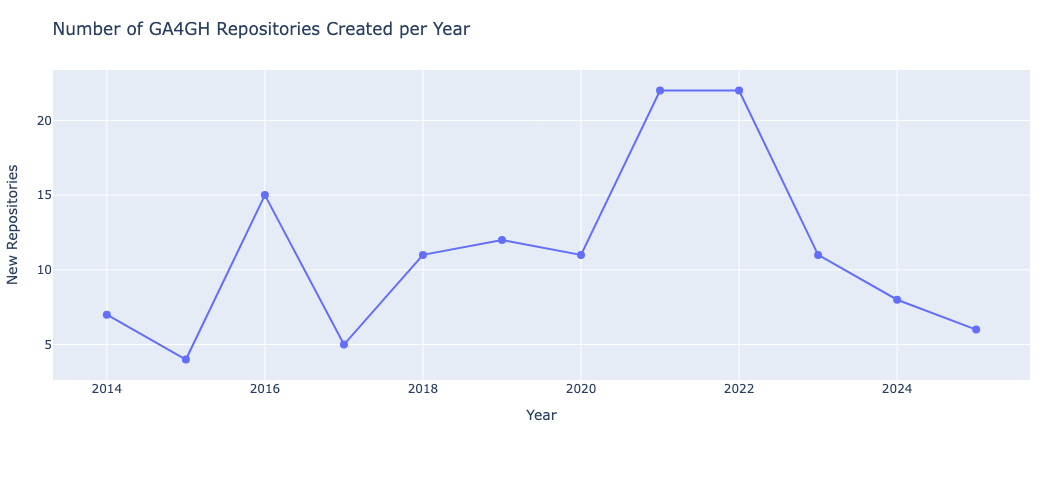

In [ ]:
GA4GH_repos = get_json(GH_repos)
GA4GH_repos_names = [repo['name'] for repo in GA4GH_repos]
GA4GH_repos_created_at = [repo['created_at'] for repo in GA4GH_repos]

df = pd.DataFrame({"repo": GA4GH_repos_names, "created_at": pd.to_datetime(GA4GH_repos_created_at)})

df["year"] = df["created_at"].dt.year  #process date time
grouped = df.groupby("year").agg({"repo": list})
grouped["count"] = grouped["repo"].apply(len)

grouped["repos_str"] = grouped["repo"].apply(lambda repos: "<br>".join(repos))

grouped = grouped.reset_index().sort_values("year")

fig2 = px.line(
    grouped,
    x="year",
    y="count",
    markers=True,
    title="Number of GA4GH Repositories Created per Year",
    labels={"year": "Year", "count": "Number of repositories"},
)

fig2.data[0].customdata = grouped[["repos_str"]].to_numpy()

fig2.update_traces(
    hovertemplate="Repos:<br>%{customdata[0]}<extra></extra>",
    marker=dict(size=8),
)

fig2.update_layout(
    xaxis_title="Year",
    yaxis_title="New Repositories",
    margin=dict(l=40, r=20, t=70, b=120),
    height=500
)

## Guaging Interest Using Open Issues

One way for users of open source software to speak their mind is to create an open issue in the repo. An open issue is a way for users to directly request new features or changes within a piece of software that can be addressed and tracked publicly by the developers. This allows for open discussion and encourages users to be directly involved and provide feedback from their perspective.

**Disclaimer:** You may note that that "ga4gh-schemas" as well as a few other repos with a high amount of open issues have been retired which means the high open issues may be due to the fact that they are no longer being addressed

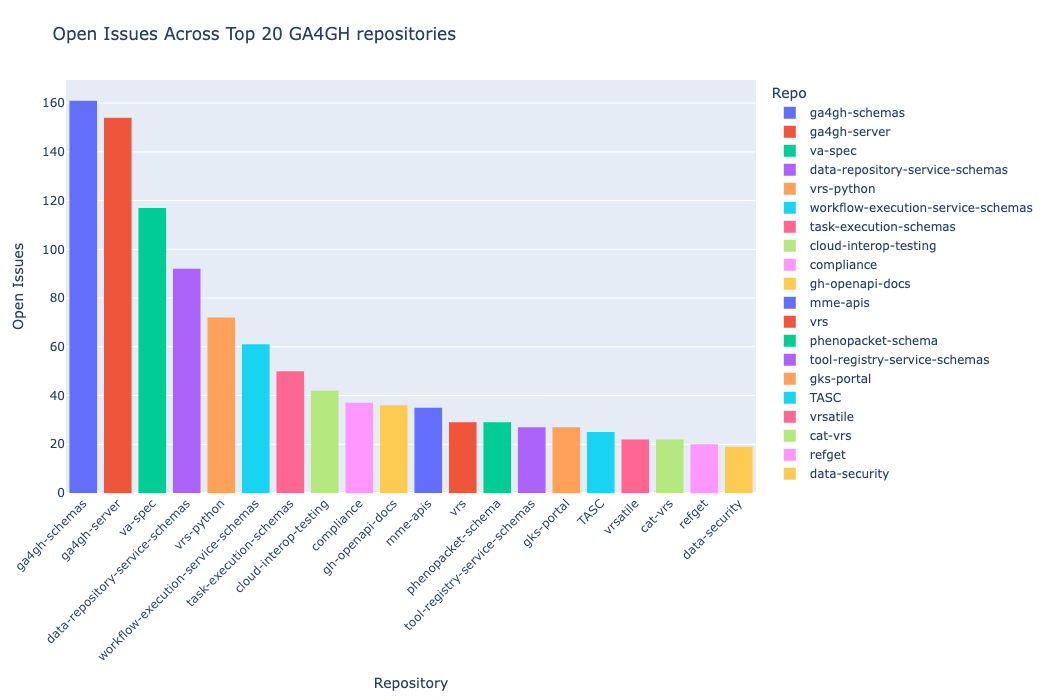

In [ ]:
# Repos with most open issues
# a bar graph highlighting the 20 repos with the most open issues

GA4GH_repos = get_repos(GH_BASE_URL, repos_list)
GA4GH_repos_names = [repo['name'] for repo in GA4GH_repos]
GA4GH_repos_issues = [repo['open_issues_count'] for repo in GA4GH_repos]

df = pd.DataFrame({"Repo": GA4GH_repos_names, "Open_issues": GA4GH_repos_issues})

df = df.sort_values("Open_issues", ascending=False).reset_index(drop=True)
df = df.head(20)

fig3 = px.bar(
    df,
    x="Repo",
    y="Open_issues",
    title="Open Issues Across Top 20 GA4GH repositories",
    hover_data=["Open_issues"],
    color='Repo'
)

fig3.update_layout(
    xaxis_tickangle=-45,
    margin=dict(l=40, r=20, t=80, b=150),
    xaxis_title="Repository",
    yaxis_title="Open Issues",
    height = 700,
)
fig3.update_traces(marker_line_width=0)

## Create All Graphs

Generate all graphs within one cell and if running locally, you can view all graphs in greater detail **[here](http://127.0.0.1:8050/)**

In [ ]:
app = Dash(__name__)
app.layout = html.Div([
    html.Div([
        html.H4("GA4GH repositories — Watchers + Stargazers + Forks"),
        dcc.Graph(id="graph", figure=fig1),
    ]),
    html.Div([
        html.H4("New GA4GH Github Repositories Added Yearly"),
        dcc.Graph(id="hist-year", figure=fig2),
    ]),
    html.Div([
        html.H4("20 GA4GH Repos With Most Open Issues"),
        dcc.Graph(id="open-issues-pie", figure=fig3),
    ])
])

app.run(debug=True)